# Final project

Alcohol consumption is a relevant public health issue, as it is associated with increased cardiovascular risk and negative effects on both physical and mental health\. Identifying individuals at risk is crucial to support early detection and to design targeted prevention strategies\. In this context, machine learning methods can help uncover patterns linking demographic and physiological factors to alcohol consumption\.

This study is based on the Smoking and Drinking Dataset with Body Signal, collected from the Korean National Health Insurance Service and publicly available on Kaggle: https://www\.kaggle\.com/datasets/sooyoungher/smoking\-drinking\-dataset\. The dataset contains anonimyzed health\-related information suitable for large\-scale behavioral and predictive analysis\. The variables analyzed include demographic attributes, lifestyle indicators, and body signal measurements obtained during clinical examinations\. 

This project addresses a binary classification task aimed at predicting alcohol consumption behavior\. The target variable is DRK\_YN, which indicates whether an individual is a drinker or not\. The goal is to build an accurate predictive model, while also identifying and interpreting the most important factors contributing to the prediction\.

In [1]:
import numpy as np
import pandas as pd
!pip install missingno
!pip install imblearn
!pip install xgboost -q
import missingno as msno 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

import itertools

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

from imblearn.pipeline import Pipeline as IMBPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn import set_config
from functools import partial

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV, cross_validate, StratifiedKFold
from sklearn.model_selection import learning_curve, validation_curve

from scipy.stats import loguniform
from scipy.stats import uniform

import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score
)

from sklearn.inspection import permutation_importance

import warnings

# Suppress warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 103.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
df = pd.read_csv("df_reduced.csv") # Load the reduced dataset from CSV file
df.info()  # Display dataset structure: columns, data types, missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178441 entries, 0 to 178440
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               178441 non-null  object 
 1   age               178441 non-null  int64  
 2   height            178441 non-null  int64  
 3   weight            178441 non-null  int64  
 4   waistline         178441 non-null  float64
 5   sight_left        178441 non-null  float64
 6   sight_right       178441 non-null  float64
 7   hear_left         178441 non-null  float64
 8   hear_right        178441 non-null  float64
 9   SBP               178441 non-null  float64
 10  DBP               178441 non-null  float64
 11  BLDS              178441 non-null  float64
 12  tot_chole         178441 non-null  float64
 13  HDL_chole         178441 non-null  float64
 14  LDL_chole         178441 non-null  float64
 15  triglyceride      178441 non-null  float64
 16  hemoglobin        17

In [3]:
df.head(10)

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,60,165,65,73.0,1.0,1.0,1.0,1.0,138.0,...,106.0,63.0,15.5,1.0,1.0,24.0,23.0,29.0,2.0,Y
1,Male,45,165,65,78.0,0.9,0.9,1.0,1.0,120.0,...,180.0,234.0,14.7,1.0,0.8,20.0,17.0,19.0,3.0,N
2,Male,40,170,65,82.0,1.0,1.0,1.0,1.0,125.0,...,169.0,94.0,15.9,1.0,0.9,30.0,51.0,49.0,1.0,Y
3,Female,50,165,65,75.0,1.0,1.2,1.0,1.0,139.0,...,172.0,94.0,13.1,1.0,0.6,34.0,21.0,27.0,1.0,N
4,Male,35,160,75,88.0,1.2,1.0,1.0,1.0,108.0,...,152.0,116.0,15.3,2.0,0.9,19.0,16.0,22.0,2.0,Y
5,Female,40,155,55,76.0,1.5,1.0,1.0,1.0,105.0,...,161.0,83.0,13.2,1.0,0.7,18.0,16.0,13.0,1.0,N
6,Female,60,155,55,79.5,1.0,1.2,1.0,1.0,127.0,...,129.0,101.0,12.0,1.0,0.8,24.0,24.0,18.0,1.0,N
7,Female,50,155,50,69.5,1.0,0.7,1.0,1.0,128.0,...,98.0,186.0,12.5,1.0,0.8,33.0,43.0,25.0,1.0,N
8,Male,50,170,75,88.0,0.7,0.3,1.0,1.0,125.0,...,173.0,108.0,15.2,1.0,1.1,35.0,58.0,42.0,1.0,Y
9,Male,45,170,75,86.0,0.8,0.6,1.0,1.0,110.0,...,72.0,332.0,13.7,1.0,1.2,39.0,31.0,29.0,3.0,Y


Since the original dataset does not contain missing values, missingness was artificially introduced in a subset of selected features to simulate real\-world data imperfections\. 

In [4]:
def introduce_missing_mcar_df(df_in, missing_rates, seed=42):
    """
    Introduce missing values (NaN) into selected columns of a DataFrame
    under the MCAR assumption.
    """
    rng = np.random.default_rng(seed)
    df_out = df_in.copy()
    n = len(df_out)

    for col, rate in missing_rates.items():
        n_missing = int(n * rate)
        idx = rng.choice(df_out.index, size=n_missing, replace=False)
        df_out.loc[idx, col] = np.nan

    return df_out


missing_plan = {
    "sight_left": 0.10,
    "sight_right": 0.10,
    "hear_left": 0.05,
    "hear_right": 0.05,
    "urine_protein": 0.08,
    "serum_creatinine": 0.05,
    "height": 0.05,
    "weight": 0.05,
    "waistline": 0.05
}

df_missing = introduce_missing_mcar_df(df, missing_plan, seed=42)

## Exploratory Data Analysis \(EDA\)

The first step of the project is an exploratory data analysis \(EDA\), conducted to provide an initial overview of the dataset, including its dimensionality, variable types, and overall data quality\. 

In [5]:
print(df_missing.shape) 

(178441, 24)


The dataset consists of 178,441 observations and 24 variables, including both input features and the target variable\. This confirms the large\-nature of the data and highlights the need for efficient preprocessing and modeling strategies\.

In [6]:
df_missing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178441 entries, 0 to 178440
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               178441 non-null  object 
 1   age               178441 non-null  int64  
 2   height            169519 non-null  float64
 3   weight            169519 non-null  float64
 4   waistline         169519 non-null  float64
 5   sight_left        160597 non-null  float64
 6   sight_right       160597 non-null  float64
 7   hear_left         169519 non-null  float64
 8   hear_right        169519 non-null  float64
 9   SBP               178441 non-null  float64
 10  DBP               178441 non-null  float64
 11  BLDS              178441 non-null  float64
 12  tot_chole         178441 non-null  float64
 13  HDL_chole         178441 non-null  float64
 14  LDL_chole         178441 non-null  float64
 15  triglyceride      178441 non-null  float64
 16  hemoglobin        17

Before visualizing the missing values, the number and percentage of missing entries per feature are computed to quantitatively assess the extent of missingness in the dataset\.

In [7]:
# Number of missing values per column
missing_counts = df_missing.isna().sum(axis=0)
print("Missing counts per column:\n", missing_counts)

# Percentage of missing values per column
missing_percentage = (missing_counts / df_missing.shape[0]) * 100
print("\nPercentage of missing entries per column:\n", missing_percentage)

Missing counts per column:
 sex                     0
age                     0
height               8922
weight               8922
waistline            8922
sight_left          17844
sight_right         17844
hear_left            8922
hear_right           8922
SBP                     0
DBP                     0
BLDS                    0
tot_chole               0
HDL_chole               0
LDL_chole               0
triglyceride            0
hemoglobin              0
urine_protein       14275
serum_creatinine     8922
SGOT_AST                0
SGOT_ALT                0
gamma_GTP               0
SMK_stat_type_cd        0
DRK_YN                  0
dtype: int64

Percentage of missing entries per column:
 sex                 0.000000
age                 0.000000
height              4.999972
weight              4.999972
waistline           4.999972
sight_left          9.999944
sight_right         9.999944
hear_left           4.999972
hear_right          4.999972
SBP                 0.000000
D

To complement the quantitative analysis of missing values, a visual inspection is performed to better understand their distribution and structure across the dataset\. Visualizing missing data is useful to identify potential patterns, such as concentration in specific features or systematic gaps across observations, which may not be immediately evident from summary statistics alone\. For this purpose, the missingno library is employed, and in particular the msno\.matrix\(\) function, which provides a compact graphical overview of the presence and location of missing values for each feature in the dataset\.

<Axes: >

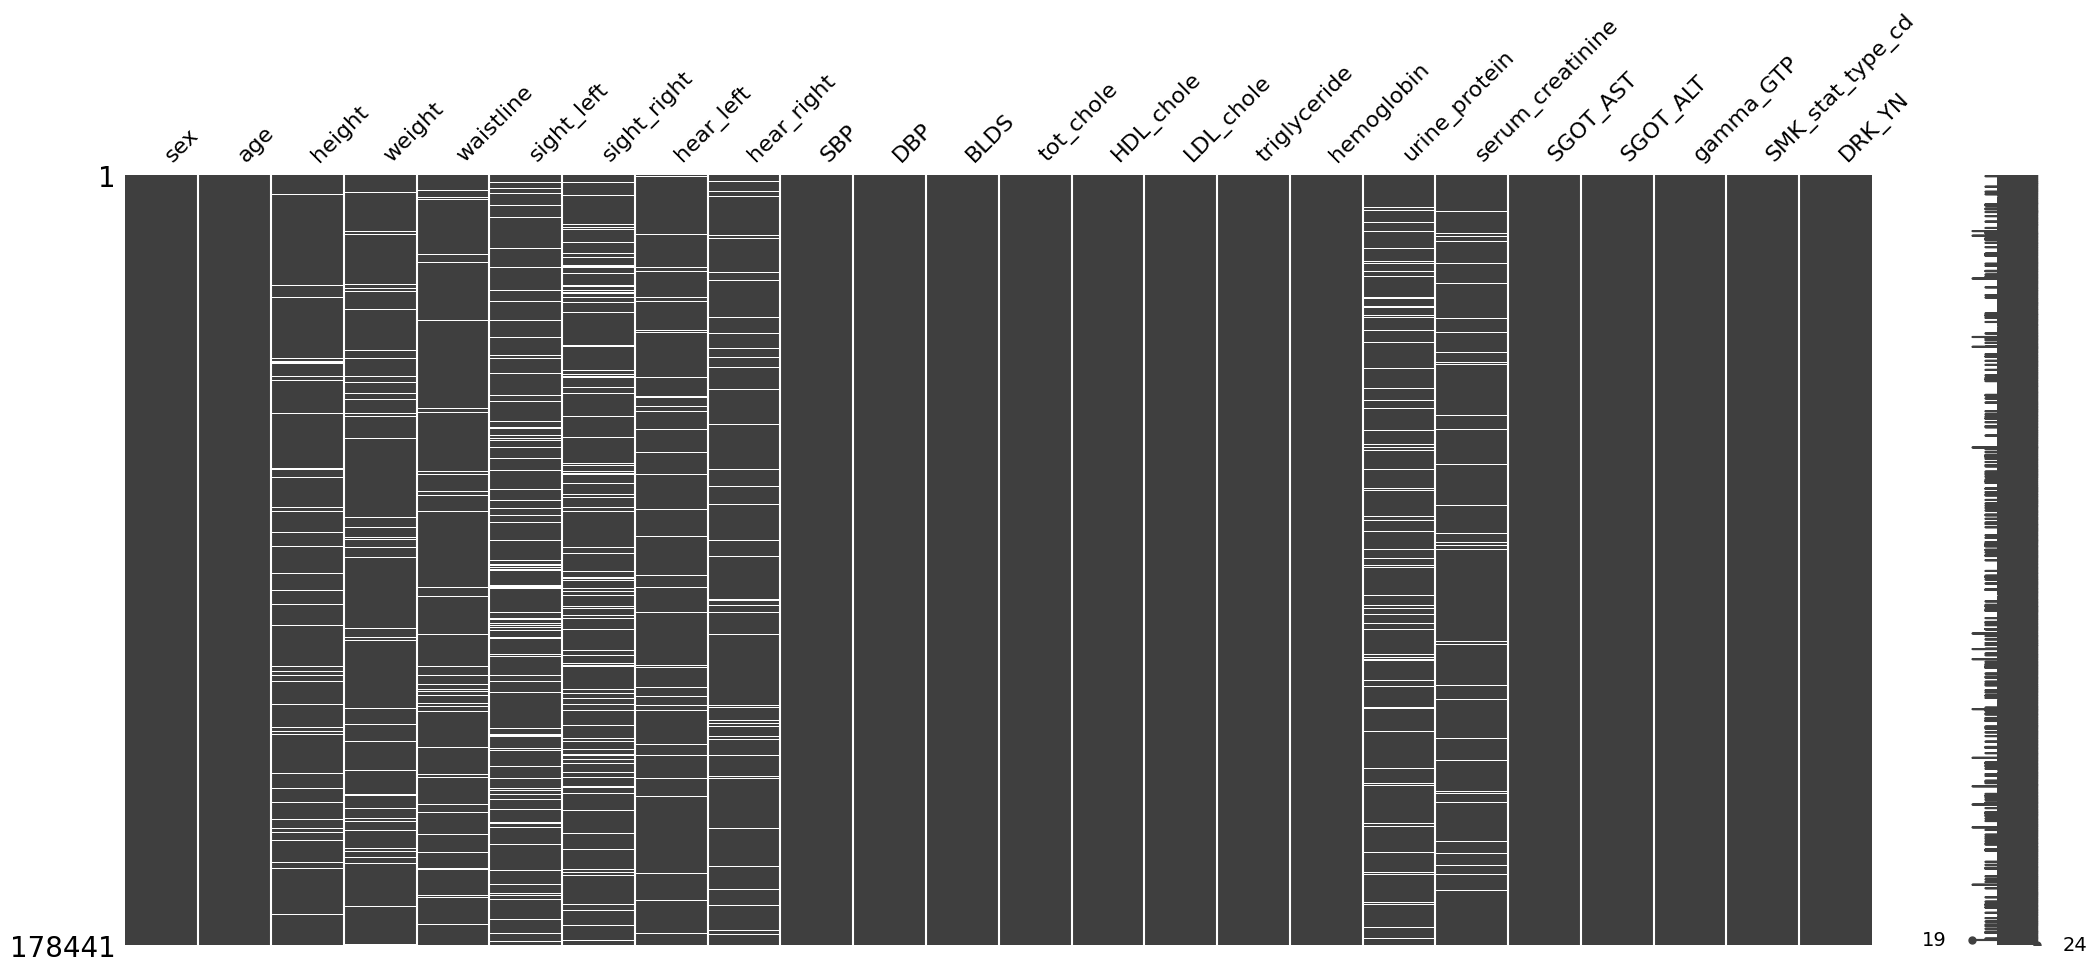

In [8]:
msno.matrix(df_missing)

Since the percentage of missing values for each feature is always below 10%, removing entire columns would be inappropriate, as it would lead to an unnecessary loss of potentially informative variables\. Therefore, all features were retained and appropriate preprocessing techniques were applied to handle missing values\.

<hr>

As a first step of the exploratory data analysis, the distribution of the target variable is examined\. Analyzing the class distribution is essential to assess the presence of potential class imbalance, which may influence both the choice of evaluation metrics and the modeling strategy adopted in the subsequent machine learning analysis\.

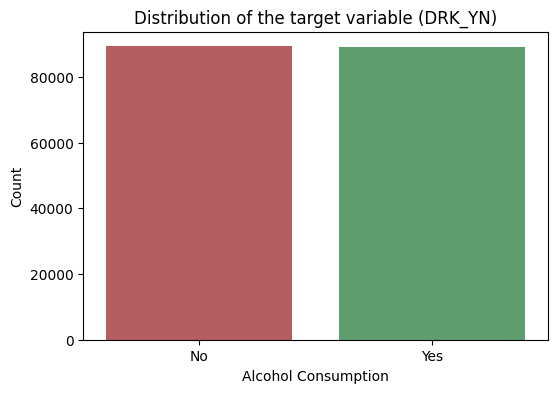

DRK_YN
N    50.018774
Y    49.981226
Name: proportion, dtype: float64

In [9]:
# Visualize the distribution of the target variable (DRK_YN)
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_missing,
    x="DRK_YN",
    order=["N", "Y"],
    hue="DRK_YN",
    palette={"N": "#C44E52", "Y": "#55A868"},
    legend=False
)

plt.title("Distribution of the target variable (DRK_YN)")
plt.xlabel("Alcohol Consumption")
plt.ylabel("Count")

# FIX: set ticks + labels together
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])

plt.show() # Display the plot

# Compute the percentage distribution of the target variable (DRK_YS)
df_missing["DRK_YN"].value_counts(normalize=True) * 100

The distribution of the target variable DRK\_YN shows a nearly balanced split between non\-drinkers \(50\.02%\) and drinkers \(49\.98%\)\. The absence of significant class imbalance justifies the use of Accuracy as a reliable metric for overall performance\. Nonetheless, Precision and Recall will also be monitored to detect any potential asymmetries in classification errors\.

The analysis now focuses on the dataset features, which are examined separately for numerical and categorical variables\. The goal is to understand the data structure, justify preprocessing choices, and explore preliminary relationships with the target variable\. Specifically:

- Numerical variables: age, height, weight, waistline, sight\_left, sight\_right, SBP, DBP, BLDS, tot\_chole, HDL\_chole, LDL\_chole, triglyceride, hemoglobin, serum\_creatinine, SGOT\_AST, SGOT\_ALT, gamma\_GTP;

- Categorical variables: sex, SMK\_stat\_type\_cd, hear\_left, hear\_right, urine\_protein\.

As a first step in the analysis of numerical features, histograms were used to explore the empirical distribution of each variable\. 

Although urine\_protein, SMK\_stat\_type\_cd and hearing\-related variables are stored as numerical values, they represent ordinal categorical information\. Therefore, they are treated as categorical features in the exploratory analysis and in subsequent preprocessing steps\.

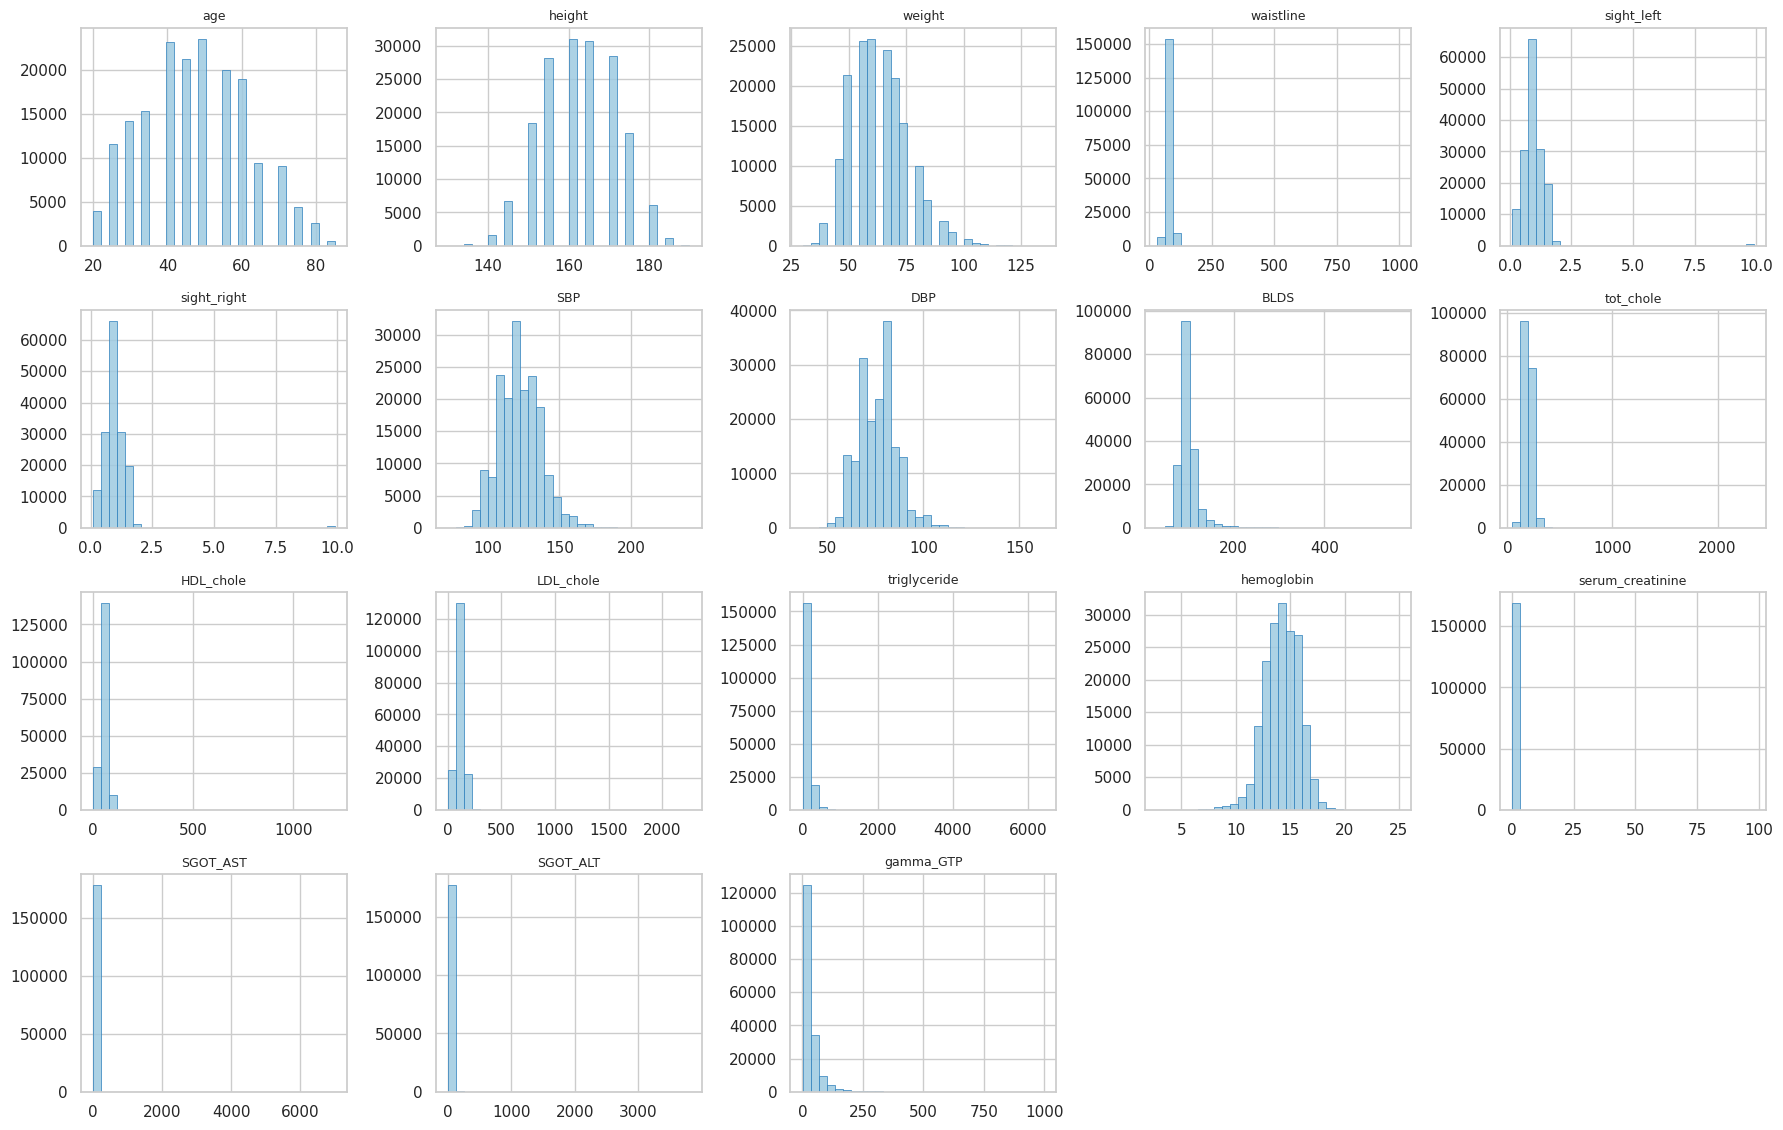

In [10]:
# Visual inspection of numerical feature distributions
sns.set(style="whitegrid")

# Select numeric columns based on data type
numerical_features = df_missing.select_dtypes(include="number").columns.tolist()

# Remove ordinal / categorical variables coded as numbers
categorical_encoded = [
    "SMK_stat_type_cd",
    "urine_protein",
    "hear_left",
    "hear_right"
]

numerical_features = [
    col for col in numerical_features if col not in categorical_encoded
]

# Plot histograms for numerical features
plt.figure(figsize=(18, 14))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(5, 5, i)
    sns.histplot(
        df_missing[col],
        bins=30,
        color="#9ECAE1",       # bars
        edgecolor="#3182BD",   # border
        alpha=0.85
    )
    plt.title(col, fontsize=9)
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()  # Display all plots

This analysis highlights a heterogeneous structure within the dataset\. 

- Demographic and anthropometric variables \(age, height, weight, and waistline\) exhibit approximately unimodal distributions\. While age shows a relatively broad spread, physical measurements like height and weight follow a near\-Gaussian distribution, centered around the population's average physical characteristics\. 

- Clinical and biochemical markers \(BLDS, triglyceride, SGOT\_AST, SGOT\_ALT, and gamma\_GPT\) display strong right skewness, characterized by a high concentration of observations at lower values and long risght tails\. This suggests that while most individuals present normal ranges, a smaller subset of the population exhibits elevated levels of these markers\.

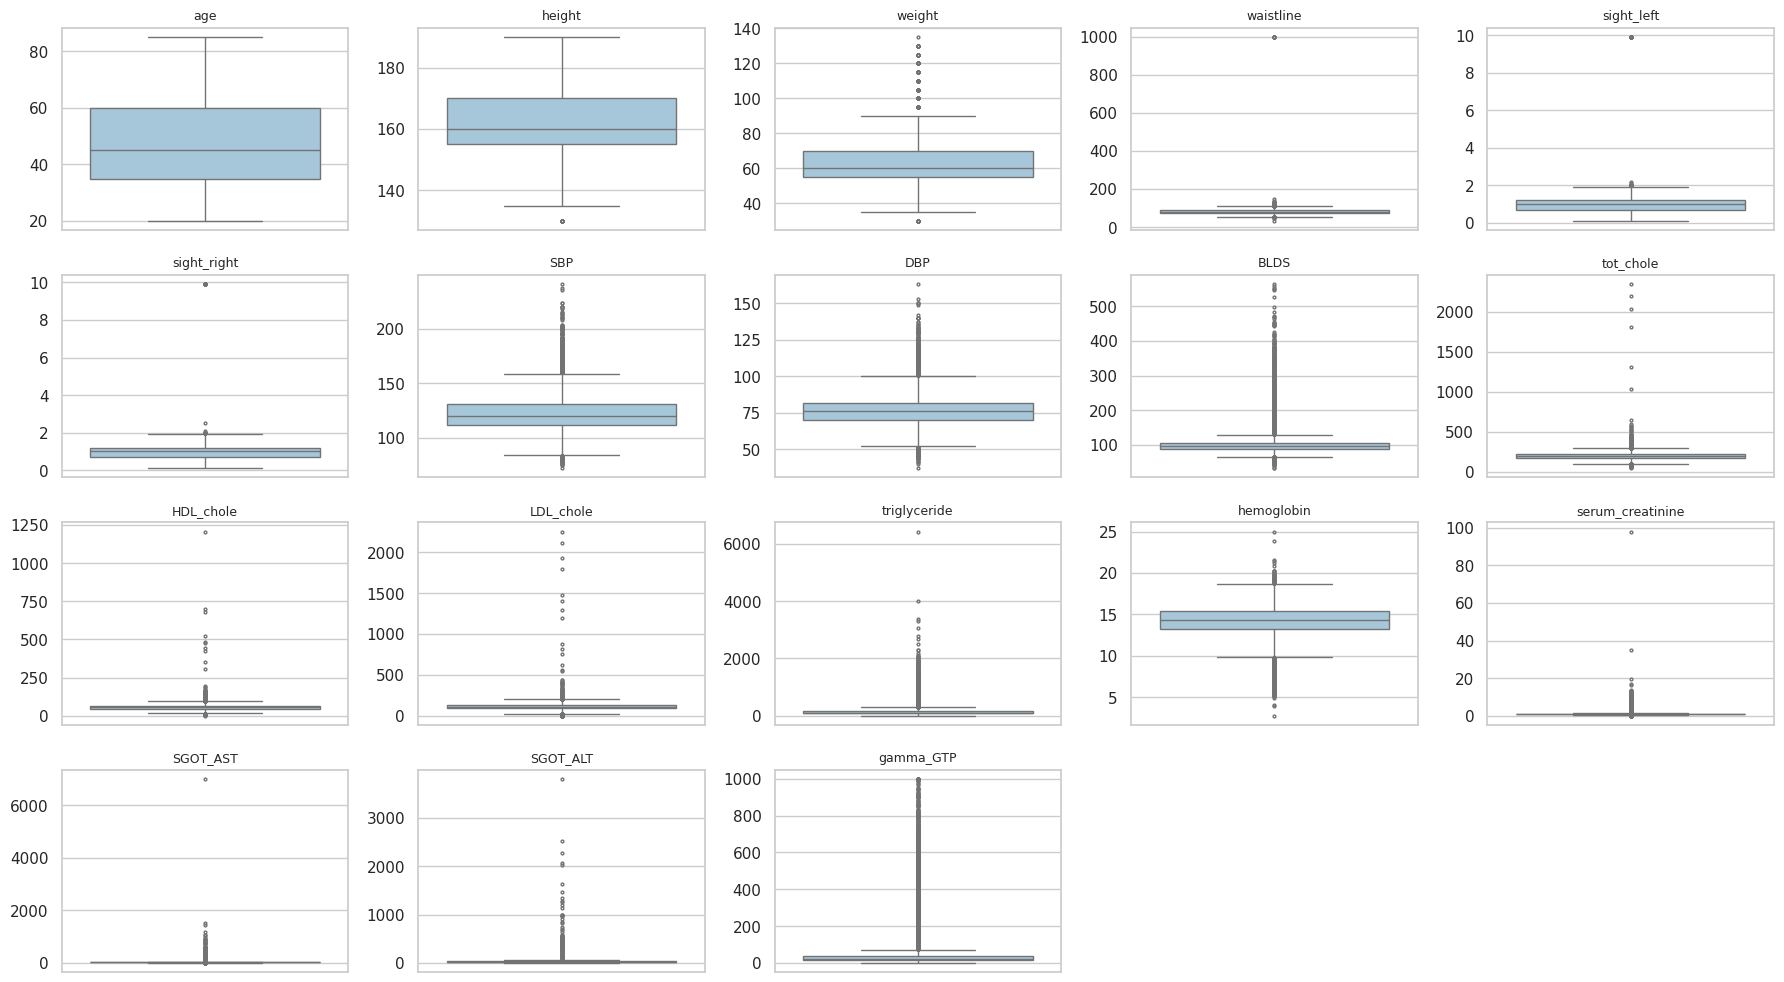

In [11]:
# Outlier analysis for numerical features using boxplots
sns.set(style="whitegrid")

numerical_features = [
    "age", "height", "weight", "waistline", "sight_left", "sight_right",
    "SBP", "DBP", "BLDS",
    "tot_chole", "HDL_chole", "LDL_chole",
    "triglyceride", "hemoglobin", "serum_creatinine",
    "SGOT_AST", "SGOT_ALT", "gamma_GTP"
]

plt.figure(figsize=(18, 10))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(4, 5, i)
    sns.boxplot(
        y=df_missing[col],
        color="#9ECAE1",
        fliersize=2
    )
    plt.title(col, fontsize=9)
    plt.ylabel("")

plt.tight_layout()
plt.show()  # Display all boxplots


The analysis of the boxplots for the numerical variables reveals that several features, especially those related to biochemical and clinical measurements, exhibit highly asymmetric distributions characterized by long right tails and the presence of numerous extreme values\. These patterns are fully consistent with the skewed distributions previously observed in the histogram analysis\.

Importantly, the detected outliers do not appear to be the result of measurement errors or data corruption\. On the contrary, they represent clinically plausible values that may reflect real physiological or pathological conditions, such as elevated triglycerides, liver enzymes, or glucose levels\. For this reason, removing these observations would lead to a loss of meaningful information and could introduce bias into the dataset\. Missing values in numerical variables are imputed using the median rather than the mean, as the median is less sensitive to extreme observations and provides a more representative measure of central tendency for skewed distributions\.

Furthermore, numerical features are scaled using a robust scaling approach\. Specifically, the RobustScaler is preferred over standard normalization techniques because it relies on the median and interquartile range, making it more resilient to the influence of outliers and ensuring that features with long tails do not disproportionately affect the learning process\.

After analyzing numerical features, the exploratory analysis focuses on categorical variables\. The objective is to understand their distribution within the dataset and to explore potential associations with the target variable \(DRK\_YN\)\. This step provides preliminary insights into which categorical features may be informative for alcohol consumption prediction and helps guide encoding and feature selection choices in the modeling phase\.

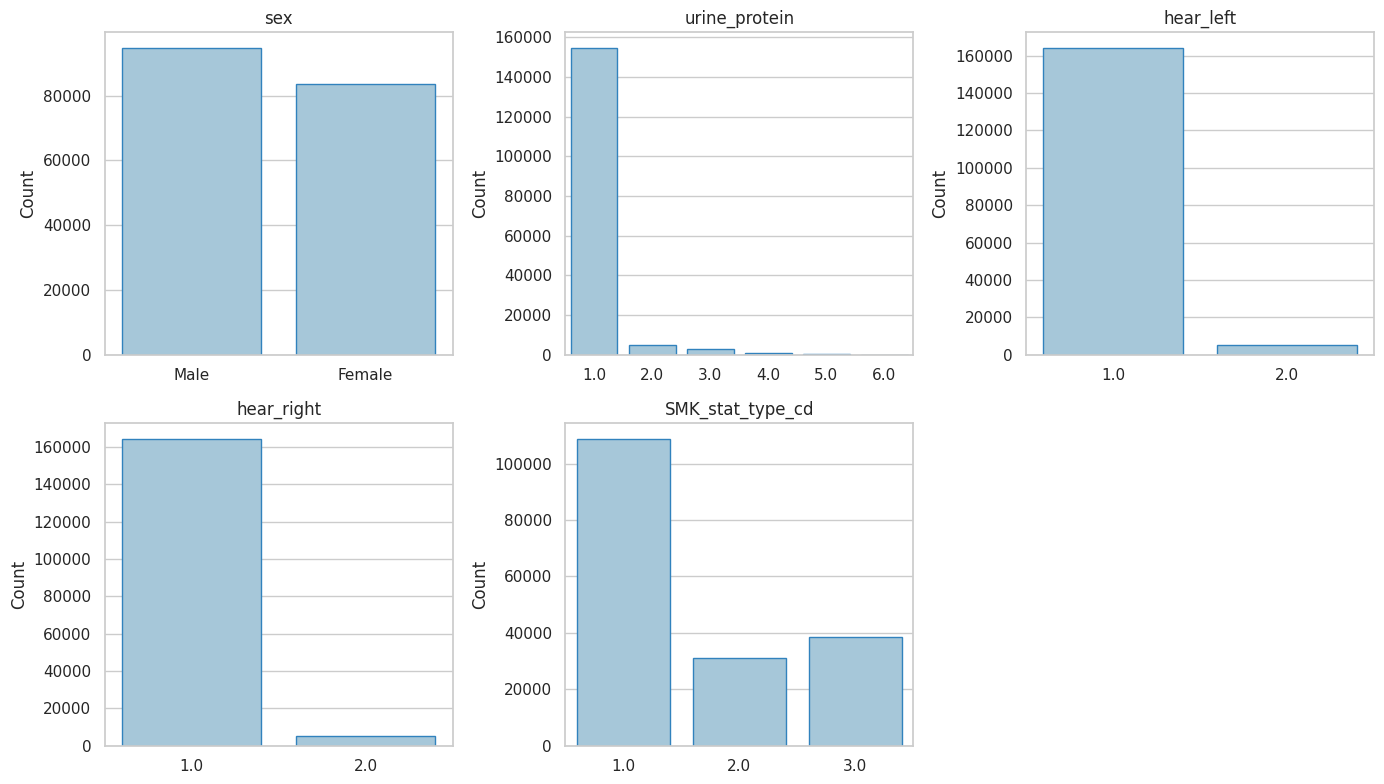

In [12]:
# Visual inspection of categorical feature distributions
categorical_features = [
    "sex",
    "urine_protein",
    "hear_left",
    "hear_right",
    "SMK_stat_type_cd"
]

plt.figure(figsize=(14, 8))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(
        data=df_missing,
        x=col,
        color="#9ECAE1",
        edgecolor="#3182BD"
    )
    plt.title(col)
    plt.xlabel("")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()   # Display all plots

To avoid distorsions due to different group sizes, categorical variables were compared to the target using row\-normalized proportions\. This representation allows a meaningful comparison of alchol consumption rates across categories\. 

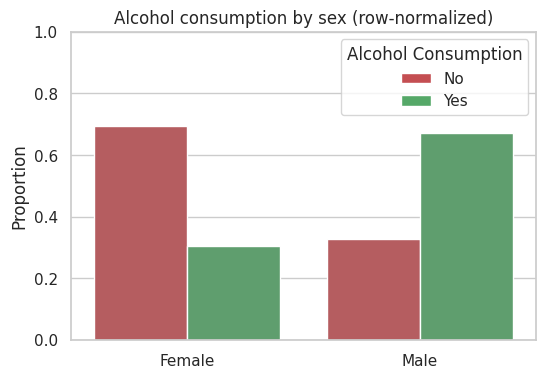

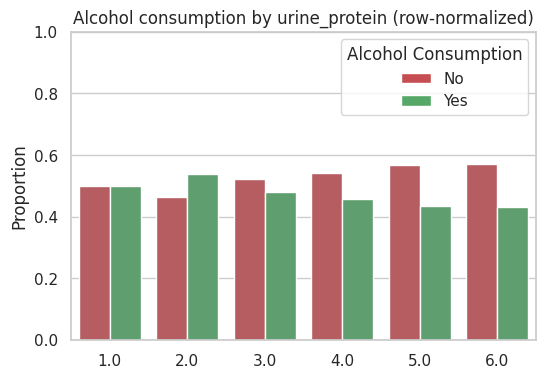

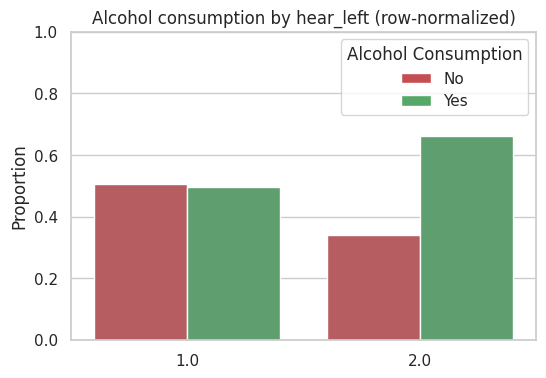

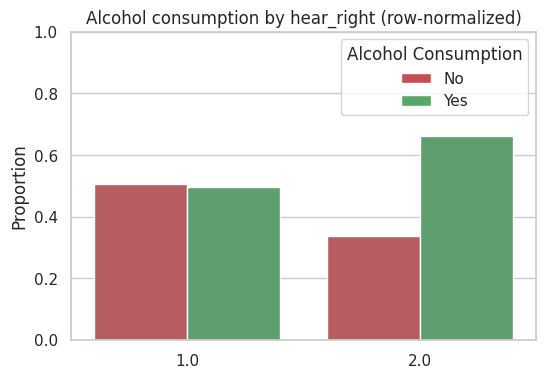

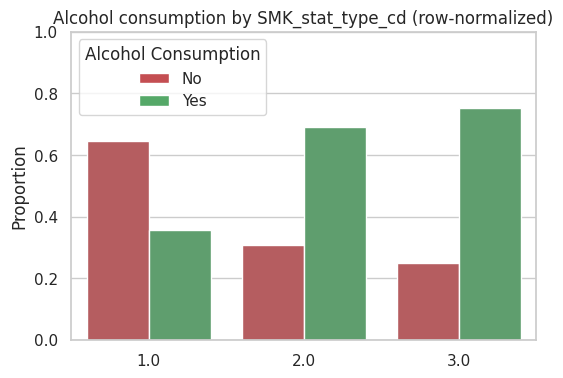

In [13]:
sns.set(style="whitegrid")

categorical_features = [
    "sex",
    "urine_protein",
    "hear_left",
    "hear_right",
    "SMK_stat_type_cd"
]

# Custom legend handles
legend_elements = [
    Patch(facecolor="#C44E52", label="No"),
    Patch(facecolor="#55A868", label="Yes")
]

for col in categorical_features:
    
    prop_df = (
        df_missing
        .groupby(col)["DRK_YN"]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )
    
    plt.figure(figsize=(6, 4))
    
    sns.barplot(
        data=prop_df,
        x=col,
        y="proportion",
        hue="DRK_YN",
        palette=["#C44E52", "#55A868"]
    )
    
    plt.title(f"Alcohol consumption by {col} (row-normalized)")
    plt.ylabel("Proportion")
    plt.xlabel("")
    plt.ylim(0, 1)
    
    # Force correct legend colors
    plt.legend(
        handles=legend_elements,
        title="Alcohol Consumption"
    )
    
    plt.show()

The use of row\-normalized proportions highlights significant disparities in alcohol consumption across categories, effectively removing the bias of group size\. Specifically, sex and smoking status \(SMK\_stat\_type\_cd\) exhibit clear variations in consuption rates, suggesting that these variables may be informative for the prediction task\. In contrast, variables such as hearing and urine protein exhibit nearly identical distributions between drinkers and non\-drinkers, indicating a weaker association at the exploratory level\.

Sensory Features analysis: Hearing and Sight\. The normalized analysis of hearing\-related variables \(hear\_left, hear\_right\) indicated that auditory capability does not significally influence the porbability of being a drinker\. This suggests that other sensory markers, like vision, might also be uninformative\. 

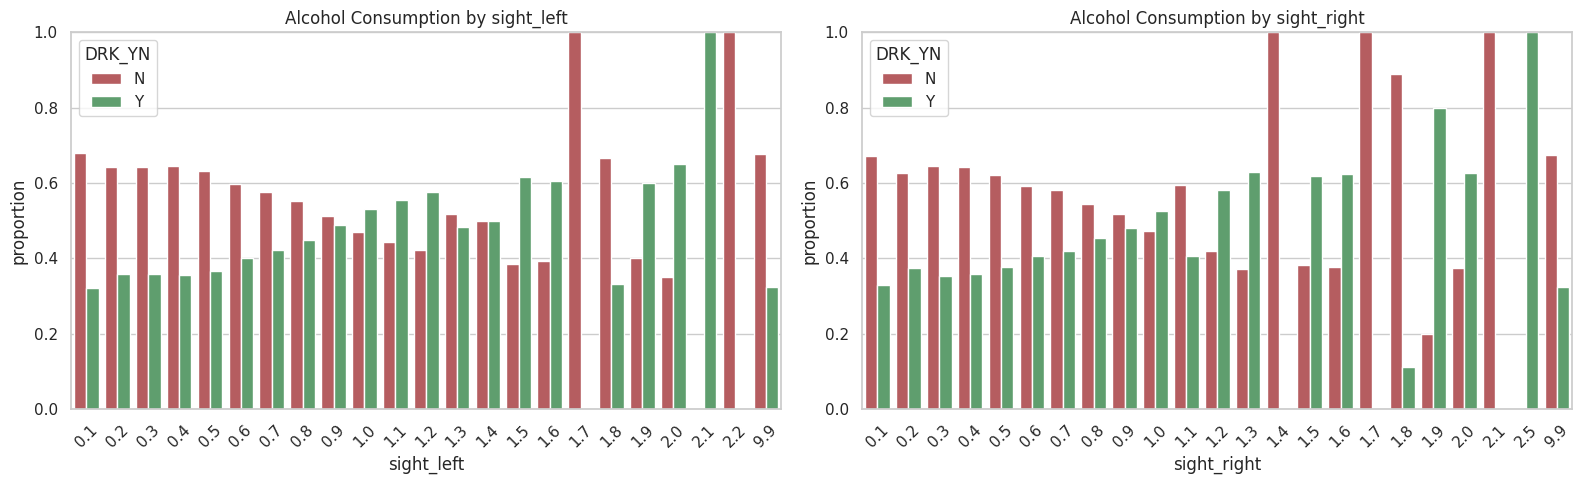

In [14]:
# Comparative visualization of sight_left and sight_right
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(["sight_left", "sight_right"]):
    # Compute class proportions for each category
    prop_df = (
        df_missing.groupby(col)["DRK_YN"]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )
    
    # Plot class proportions by category
    sns.barplot(data=prop_df, x=col, y="proportion", hue="DRK_YN", 
                ax=axes[i], palette=["#C44E52", "#55A868"])
    axes[i].set_title(f"Alcohol Consumption by {col}")
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

This check on sight\_left and sight\_right confirmed this: the distribution of drinkers remains stable across vision levels\. The minor fluctuations observed are considered statistical noise \(due to fewer samples in extreme categories as I saw in the boxplot\)\. Consequentially, all sensory features will be excluded from the pipeline to ensure a cleaner and more robust model\. 

To further explore the relationships among numerical features, a correlation heatmap is used\. This visualization helps identify highly correlated variables and multicollineartity within the feature set, supporting informed preprocessing and modeling decisions\.

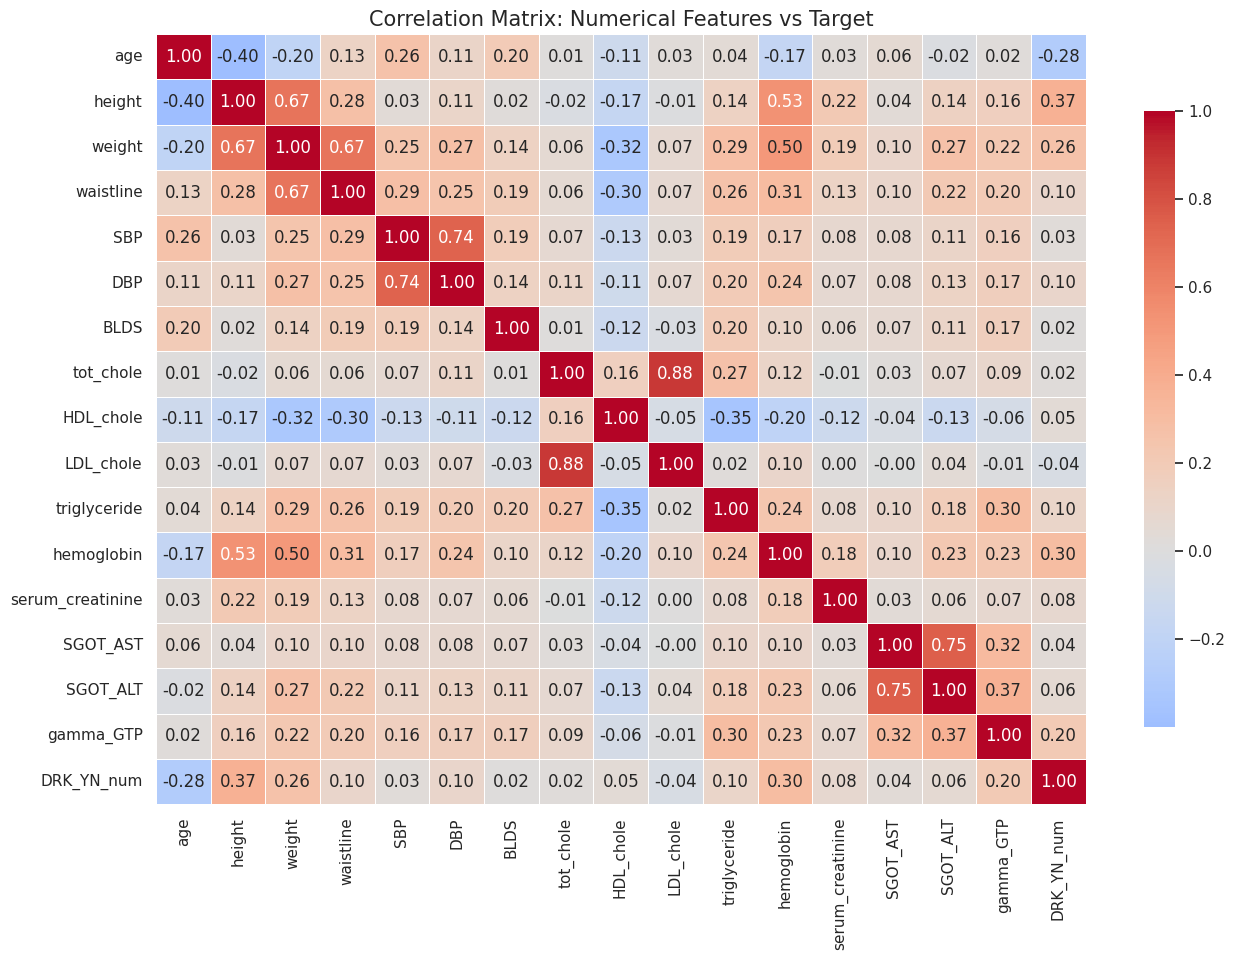

In [15]:
# Create a copy to avoid modifying the original dataframe
df_analysis = df_missing.copy()

# Map the target variable to numeric (Y=1, N=0) to calculate correlations
df_analysis['DRK_YN_num'] = df_analysis['DRK_YN'].map({'Y': 1, 'N': 0})

# Select numerical columns (excluding categorical variables where linear correlation is not applicable)
cols_for_corr = [
    "age", "height", "weight", "waistline", "SBP", "DBP", "BLDS",
    "tot_chole", "HDL_chole", "LDL_chole", "triglyceride", "hemoglobin",
    "serum_creatinine", "SGOT_AST", "SGOT_ALT", "gamma_GTP", "DRK_YN_num"
]

# Calculate the Pearson correlation matrix
corr_matrix = df_analysis[cols_for_corr].corr()

# Visualization
plt.figure(figsize=(15, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Display correlation coefficients in each cell
    fmt=".2f",           # Round values to 2 decimal places
    cmap='coolwarm',     # Use a diverging color map (red for positive, blue for negative)
    center=0,            # Center the color map at zero
    linewidths=.5,       # Add spacing between cells
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix: Numerical Features vs Target", fontsize=15)
plt.show()

The heatmap reveals several clusters of high multicollinearity:

- A very high correlation \(r = 0\.88\) exists between tot\_chole and LDL\_chole\. These two variables carry almost the same information\. keeping both could lead to multicollinearity, which might destabilize some models, particularly linear ones\. 

- Systolic \(SBP\) and Diastolic \(DBP\) blood pressures show a strong positive correlation \(r= 0\.74\)\. This is expected, as they are two measures of the same physiological system\. While both are important, their high correlation suggests they provide a combined signal of cardiovascular health\.

- Both height and hemoglobin show a significant positive correlation with the target variable DRK\_YN, likely acting as a proxy for gender\. Since males generally exhibit higher values for these traits and higher alcohol consuption rates, the model may use these features to indirectly infer gender\. 

- gamma\_GPT shows one of the strongest linear correlations with the target variable DRK\_YN, indicating a potential relationship that will be further evaluated during modeling\.

## Preprocessing

The results obtained during the Exploratory Data Analysis \(EDA\) phase directly informed the preprocessing decision adopted in this section\. In particular, the analysis revealed the presence of strongly skewed distributions, clinically olausible extreme values, a moderate proportion of missing values, and some degree of multicollinearity among features\.

The main objective of the preprocessing stage is therefore to preserve relevant information while reducing potential distorsions in the model learning process and minimizing the risk of data leakage\. 

Before applying any preprocessing transformations, the target variable is separated from the feature set\. This step is essential to prevent data leakage, ensuring that information from the target variable does not inadvertently influence the transformations applied to the input features\. 

In [16]:
# Separate features and target to prevent data leakage
X = df_missing.drop(columns=["DRK_YN"])
y = df_missing["DRK_YN"]

# Mapping of the binary target from 'Y'/'N' to 1/0 for modeling purposes
if y.dtype == "object":
    y = y.map({"N": 0, "Y": 1})

Handling of Missing Values: the Eda showed that missing values account for less than 10% of each feature and do not follow systematic patterns\. Therefore, no variables were removed\. 

- Numerical features are imputed using the median, due to its robustness to skewed distributions and outliers;

- Categorical features are imputed using the most frequent category\.

All imputation steps are integrated into the preprocessing pipeline and learned exclusively on the training set, in order to prevent data leakage\.

Sensory features related to vision and hearing are excluded from the modeling pipeline, as they were found to be non\-informative during the EDA phase\. 

Outlier Handling Strategy: Boxplot analysis revealed the presence of extreme values, particularly in clinical and biochemical variables\. However, these values appear clinically plausible and no explicit outlier removal is performed in order to avoid information loss and potential bias\. 

Multicollinearity Considerations: The correlation analysis highlighted strong linear relationship among several numerical features, most notably between tot\_chole and LDL\_chol and between SBP and DBP\. All features were retained at this stage, and the impact of multicollinearity is addressed during the modeling phase\. Since height and weight are intrinsically correlated, a derived feature \(BMI\) is introduced to capture their combined effect and reduce feature redundancy\.

### Data Transformation Pipeline

Once the set of features to retain has been defined, we proceed by defining, and not yet applying, the data transformation pipeline\. Its purpose is to clearly describe which preprocessing steps are assigned to each group of features\. 

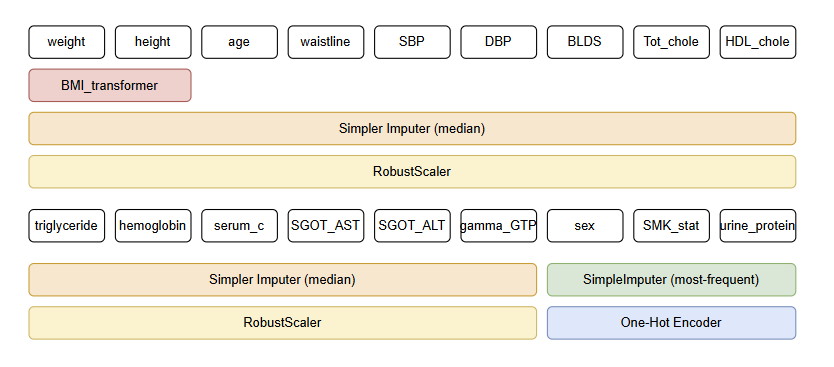

In [3]:
from IPython.display import Image, display

display(Image("file_input_uploads/Column_transformer.png"))

In our case, the preprocessing pipeline is structured as follows:

Numerical features are processed through a dedicated pipeline composed of:

- a SimpleImputer with median strategy, to robustly handle missing values;

- a RobustScaler, to reduce the influence of long\-tailed distributions and outliers\. Although some variables \(such as age, height and weight\) exhibit approximately Gaussian distributions, and could be scaled using a StandardScaler, a robust scaling strategy is applied to all numerical features\. This choice ensures homogeneous and model\-agnostic preprocessing\. Moreover, for Gaussian variables, the median closely approximates the mean, resulting in minimal differences between robust and standard scaling\.

Categorical features are processed through a separate pipeline composed of:

- a SimpleImputer with most\-frequent strategy used to handle missing values;

- an One\-Hot Encoding step to transform categorical values into numerical representations suitable for machine learning models\. Although some categorical variables exhibit a natural ordering, OrdinalEncoding is avoided because category distances are not quantitatively meaningful\. 

As part of a minimal and domain\-informed feature engineering step, height and weight are not directly passed to the numerical pipeline\. Instead, they are combined through a custom transformer to compute the Body Mass Index \(BMI\), a standard clinical indicator of body composition\. This transformation provides a more informative representation while preserving interpretability\. 
BMI = weight \(kg\) / \(height \(m\)\)²

In [17]:
# Custom Transformer to calculate Body Mass Index (BMI)
class BMITransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self  # No fitting required: BMI is a deterministic transformation

    def transform(self, X):
        # Ensure compatibility with both pandas DataFrame and numpy array
        X_arr = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)

        # Extract weight (kg) and height (cm)
        weight = X_arr[:, 0].astype(float)
        height_m = X_arr[:, 1].astype(float) / 100.0  # convert cm to meters

        # Compute BMI = weight / height^2
        bmi = weight / (height_m ** 2)

        # Return 2D array as required by sklearn
        return bmi.reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array(["bmi"], dtype=object)  # Name of the engineered feature

All transformations are combined through a ColumnTransformer, which applies the appropriate pipeline to each group of features and discards non\-selected columns\. The resulting outputs are concatenated into a unified feature matrix used for model training\.

In [18]:
# 1. Update features lists: REMOVE 'weight' and 'height' from numerical_features
# because they are now captured by the BMI Transformer.
numerical_features = [
    "age", "waistline", "SBP", "DBP", "BLDS",
    "tot_chole", "HDL_chole", "LDL_chole", "triglyceride",
    "hemoglobin", "serum_creatinine", "SGOT_AST", "SGOT_ALT", "gamma_GTP"
]

categorical_features = [
    "sex", "SMK_stat_type_cd", "urine_protein"
]

# 2. Specific Pipeline for BMI
# It calculates BMI first, then handles potential missing values and scales
pipeline_bmi = Pipeline(steps=[
    ("bmi_calc", BMITransformer()),
    ("imputer", SimpleImputer(strategy="median")), # Replace missing values with median
    ("scaler", RobustScaler())                     # Scale using robust statistics
])

# 3. Standard Pipeline for other numerical features
pipeline_numerical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# 4. Standard Pipeline for categorical features
pipeline_categorical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")) # One-hot encode categories
])

# 5. Final ColumnTransformer
data_transformation = ColumnTransformer(
    transformers=[
        ("bmi", pipeline_bmi, ["weight", "height"]), # we pass ['weight', 'height'] ONLY to the BMI pipeline
        ("numerical", pipeline_numerical, numerical_features),
        ("categorical", pipeline_categorical, categorical_features)
    ],
    remainder="drop", # Discards sensory features and any other unspecified columns
    verbose_feature_names_out=False
)

# Preview the diagram
data_transformation

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bmi', ...), ('numerical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_nam

## Training and Test set

After defining the preprocessing pipeline, the dataset is split into training and test sets in order to obtain an unbiased evaluation of the model's generalization performance on unseen data\.

Specifically, 80% of the observations are assigned to the training set, while the remaining 20% are reserved for the test set\. A stratified split is applied to preserve the original class distribution of the target variable DRK\_YN in both subsets, which is particularly important in classification tasks to avoid introducing artificial class imbalance\.

Suffling is performed implicitly by training\_test\_split and is not explicitly specified in the code\. This step is fundamental to avoid order\-related biases and to ensure representative training and test sets\. 

The preprocessing pipeline is fitted exclusively on the training set and subsequently applied to the test set, ensuring that all transformation parameyers are learned solely from training data\. 

In [19]:
y = df_missing["DRK_YN"].map({"N": 0, "Y": 1}).astype(int)

# 1. Perform the Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,  # 20% of the data used as test set
    random_state=42,      # Ensure reproducible training-test split
    stratify=y            # Preserve class distribution
)

# 2. Fit and Transform the Training Set; Transform the Test Set
X_train_transformed = data_transformation.fit_transform(X_train)
X_test_transformed = data_transformation.transform(X_test)

print(f"Data successfully split and transformed.")
print(f"Training set: {X_train_transformed.shape}, Test set: {X_test_transformed.shape}")

Data successfully split and transformed.
Training set: (142752, 23), Test set: (35689, 23)


Although the preprocessing stage retains 16 conceptual features after feature selection and feature engineering, the final transformed feature matrix contains 23 features due to the expansion of categorical variables through one\-hot encoding\. 

For example, the categorical variable urine\_protein, which takes six plausible values \(from 1 to 6\), is transformed into five binary indicator variables with drop="first"\. Each indicator represents the presence of a specific category, while the first category is used as the reference level and represented by a vector of zeros\. 

## Model Selection

In this section, the goal is to identify the most suitable predictive model for the target variable DRK\_YN by jointly selecting the model architecture and its hyperparameters\. To obtain a reliable estimate of model performance, multiple candidate configurations are evaluated within a unified framework\. Each configuration is defined as a pipeline which is composed of the following conceptual blocks:

- Data transformation \(trans\): it applies the preprocessing steps defined in the previous section\. 

- Sampling strategy \(sampler\): it enables the use of resampling techniques to address potential class imbalance\. 

- Dimensionality reduction \(dim\_reduction\): it allows the evaluation of feature space compression techniques in order to assess their impact on model performance and generalization\. 

- Classifier \(classifier\): it corresponds to the predictive model\. 

The pipeline defined below is a template with a fixed structure used to guide the model selection process\. Each component corresponds to a step of the workflow, while its specific configuration is chosen during model selection\. 

- The sampler step is initially set to None because the target variable is nearly balanced\. Instead of applying resampling by default, this component remains configurable to compare models trained with and without sampling, adding complexity only if it improves performance\. 

- The dimensionality reduction step is also initialized as None\. Given the mdoerate feature dimensionality after preprocessing, it is not required a priori\. However, keeping this placeholder allows techniques to be evaluated during model selection without changing the pipeline structure\. 

- Logistic Regression is used as a placeholder classifier to provide a simple and stable baseline\. Indeed this model is well suited for binary classification tasks and naturally handles numerical and one\-hot encoded features\. 

In [20]:
# Pipeline template: fixed structure, components replaced by search.
# Data_transformation is included here to avoid leakage in CV.
model_pipeline = IMBPipeline(steps=[
    ("trans", data_transformation),
    ("sampler", None),         # to be configured
    ("dim_reduction", None),   # to be configured
    ("classifier", LogisticRegression())  # placeholder, will be replaced via configs
])

A preliminary sanity check is performed by fitting the complete pipeline on the training set and generating predictions on the test set, in order to visually inspect the pipeline structure and verify that all components interact correctly\.

In [21]:
set_config(display="diagram")
model_pipeline.fit(X_train, y_train)

,steps,"[('trans', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bmi', ...), ('numerical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formattin

In [22]:
model_pipeline.predict(X_test)

array([0, 0, 0, ..., 0, 0, 1])

After defining the pipeline template, a set of admissible configurations is specified for each configurable component of the pipeline\. The idea is to explore different modeling strategies while keeping the overall complexity aligned with the characteristics of the dataset\. 

In [23]:
#Make stochastic steps reproducible
mi = partial(mutual_info_classif, random_state=42)     # MI has randomness -> fix it
ros = RandomOverSampler(random_state=42)               # oversampling randomness -> fix it

In [24]:
#Define the search space (all admissible configurations)
dim_reduction_configs = [
    {"dim_reduction": [None]},  # bypass
    {
        "dim_reduction": [TruncatedSVD(random_state=42)],
        "dim_reduction__n_components": [10, 15, 20]  # you have ~23 features now, keep it modest
    },
    {
        "dim_reduction": [SelectKBest(score_func=mi)],
        "dim_reduction__k": [10, 15, "all"]
    }
]

sampler_configs = [
    {"sampler": [None]},  # bypass
    {
        "sampler": [ros],
        "sampler__sampling_strategy": ["minority", 0.8, 1.0]
    }
]

classifier_configs = [
    {
        "classifier": [LogisticRegression(solver="saga", max_iter=3000, n_jobs=-1)],
        "classifier__C": loguniform(1e-3, 1e2),
        "classifier__penalty": ["l1", "l2"],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier": [LinearSVC()],
        "classifier__C": loguniform(1e-3, 1e2),
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier": [RandomForestClassifier(random_state=42, n_jobs=-1)],
        "classifier__n_estimators": [200, 500],
        "classifier__max_depth": [None, 5, 10],
        "classifier__min_samples_split": [2, 10]
    },
    {
        "classifier": [XGBClassifier( random_state=42, eval_metric="logloss", n_jobs=1)],
        "classifier__n_estimators": [200, 400],
        "classifier__learning_rate": [0.03, 0.1],
        "classifier__max_depth": [3, 5],
        "classifier__scale_pos_weight": [1.0],
        "classifier__subsample": [0.8, 1.0]
    }
    
]

Let's comment each choice: 

Sampling strategy configurations: 

- No sampler \(None\): the original class distribution is preserved\. This option represents the baseline scenario and is appropriated due to the balanced target variable\. 

- RandomOverSampler: increases the number of samples from the minority class by duplicating existing observations\. This strategy is included to evaluate whether mild class balancing improves classification performance or stability\. 

Dimensionality reduction configurations:

- No dimensionality reduction \(None\): the baseline scenario in which all engineered features are retained\. 

- TruncatedSVD: it projects the original feature space onto a lower\-dimensional linear subspace by preserving the directions of maximum variance\. It is included to evaluate whether a compact representation of the features reduces noise and improves generalization\. The number of components is kept moderate \(10\-20\)\.

- Feature selection via mutial information \(selectKBest\): it selects the top k features that exhibit the strongest statistical dependency with the target variable, retaining only the most informative inputs\. This strategy is chosen because it can capture non\-linear relationships between features and the target, which is particularly relevant in health\-related data\. 

Classifier configurations: 

- Logistic Regression: linear probabilistic classifier that models the log\_odds of the target as a linear combination of the input features\. It serves as an interpretable baseline model\. 

- Linear Support Vector Classifier: it is a margin\-based linear classifier that seeks an optimal separating hyperplane between classes\. It is sensitive to feature scaling, making it well suited for the standardized feature space oriduced by the preprocessing pipeline, and provides a strong linear alternative to logistic regression\.

- Random Forest: it is an ensemble method based on multiple decision trees trained on bootstrapped samples\. It can naturally model non\-linear relationships and feature interactions, and is included to assess the benefit of tree\-based ensemble learning on tabular clinical data\.

- XGBoost: it is a gradient boost algorithm that builds an esemble of trees sequentially, where each tree corrects the errors of the previous ones\. It is capable of capturing complex non\-linear patterns and feature interactions\. The hyperparameter ranges are intentionally constrained to limit overfitting and ensure computational efficiency\. 

The full configuration space is generated by computing the Cartesian Product of the sampler, dimensionality reduction and classifier configurations using the intertools\.product function\. For each combination, the corresponding parameter dictionaries are merge into a single configuration using itertools\.chain\. This function concatenates the key\-value pairs associated with each pipeline components into one unified dictionary, chich can be directly used in the model selection process\. 

In [25]:
# cartesian product: list of all possible configurations
all_configs = [
    dict(itertools.chain(*(d.items() for d in combo)))  # merge sampler+dim+clf dicts
    for combo in itertools.product(sampler_configs, dim_reduction_configs, classifier_configs)
]

print(f"Total number of configurations: {len(all_configs)}")  # sanity check
all_configs[:2]

Total number of configurations: 24


[{'sampler': [None],
  'dim_reduction': [None],
  'classifier': [LogisticRegression(max_iter=3000, n_jobs=-1, solver='saga')],
  'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7fece8523290>,
  'classifier__penalty': ['l1', 'l2'],
  'classifier__class_weight': [None, 'balanced']},
 {'sampler': [None],
  'dim_reduction': [None],
  'classifier': [LinearSVC()],
  'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7fece8523a50>,
  'classifier__class_weight': [None, 'balanced']}]

The resulting search space contains 24 admissible pipeline configurations, confirming that the seach space is correctly defined and computationally manageable\. 

Model selection is performed using an inner cross\-validation loop implemented with RandomizeSearchCV\. The objective of this step is to identify the most suitable pipeline configuration and hyperparameters using only the training data\. A StratifiedKFold with 2 splits is used as the inner cross\-validation strategy: training data are repeatedly split into subsets, allowing the model to be trained and validated on different portions of the data\. This reduces sensitivity to a single train\-validation split and leads to more robust model comparison\. 

- n\_splits = 2 is selected to limit computational cost, given the relatively large dataset size and the high number of candidate configurations\. 

- shuffle = True ensures that samples are randomly distributed across folds\. 

- random\_state = 42 guarantees reproducibility of the splits\. 

- Stratification preserves the original class distribution of the target variable in each fold\. 

The number of evaluated configurations is set to n\_iter=min\(len\(all\_configs\) \* 3,60\), ensuring sufficient exploration of the search space while keeping computational cost under control\. Model selection is based on the F1\-score, which balances precision and recall and is appropriate for binary classification with potential residual class imbalance\. 

In [26]:
inner_cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    estimator=model_pipeline,                 # pipeline to optimize
    param_distributions=all_configs,          # admissible configurations
    n_iter=min(len(all_configs) * 3,60),             # sample at least 10x
    scoring="f1",                             # selection metric
    cv=inner_cv,                              # 2-fold inner CV
    n_jobs=1,                                 # keep stable (set -1 if you want speed)
    random_state=42,                          # reproducible sampling of configs
    verbose=1,                                # show progress
    refit=True                                # refit best on each inner training split
)

The nested cross\-validation process is completed through an outer cross\-validation loop, whose purpose is to provide an unbiased estimate of the model's generalization performance\. In this outer loop, the dataset is split into five stratified folds, ensuring that the original class distribution of the target variable \(DRK\_YN\) is preserve in each split\. For each outer training fold, the entire inner model selection procedure is executed independently\. 

The optimized model obtained from the inner loop is then evaluated on the corresponding outer validation fold, which remains completely unseen during both training and hyperparameter oprimization via RandomizedSearchCV\. 

Model performance is evaluated using the F1\-score, consistently with the inner loop\. This evaluation is carried out independently on each of the five outer folds, and the resulting nF1\-scores are averaged to obtain a stable and robust estimate of the model's expected generalization performance on unseen data\. 

In [27]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    rs,                                          # inner optimizer
    X_train, y_train,                            # training data only
    scoring="f1",                                 # outer metric
    cv=outer_cv,                                  # 3 outer folds
    return_estimator=True,                        # keep the fitted search objects
    n_jobs=1,                                     # keep stable
    verbose=2                                     # show fold progress
)

print("Nested CV F1 scores:", scores["test_score"])
print("Mean F1:", scores["test_score"].mean())

Fitting 2 folds for each of 60 candidates, totalling 120 fits
[CV] END .................................................... total time=21.3min
Fitting 2 folds for each of 60 candidates, totalling 120 fits
[CV] END .................................................... total time=18.3min
Fitting 2 folds for each of 60 candidates, totalling 120 fits
[CV] END .................................................... total time=19.0min
Fitting 2 folds for each of 60 candidates, totalling 120 fits
[CV] END .................................................... total time=20.9min
Fitting 2 folds for each of 60 candidates, totalling 120 fits
[CV] END .................................................... total time=20.7min
Nested CV F1 scores: [0.74051091 0.73797977 0.73534685 0.74025393 0.74303767]
Mean F1: 0.7394258262764521
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 100.2min finished


The nested cross\-validation results show a very consistent behavior across the five outer folds\. The F1\-scores range from approximately 0\.735 to 0\.743, with a difference of less than 0\.01 between the worst and the best fold\. This limited variability indicates that the model's performance is stable and does not strongly depend on a specific data split\. Overall, these results suggest that the proposed preprocessing and modeling strategy generalizes well and yields consistent predictive performance across different subsets of the data\. 

Looking at each outer fold helps understand which combination of simpler, classifier and hyperparameters works best in different splits of the data and whether the model's performance is stable before selecting the final pipeline\. 

In [28]:
#Inspect the best pipeline selected in each outer fold
for i, search_obj in enumerate(scores["estimator"], start=1):
    best_pipe = search_obj.best_estimator_                         # best pipeline in fold i
    print(f"\nFOLD {i} | outer F1 = {scores['test_score'][i-1]:.4f}")
    print("sampler:", best_pipe.get_params()["sampler"])           # chosen sampler
    print("dim_reduction:", best_pipe.get_params()["dim_reduction"])# chosen dim method
    print("classifier:", best_pipe.get_params()["classifier"])     # chosen classifier
    print('-' * 40)



FOLD 1 | outer F1 = 0.7405
sampler: None
dim_reduction: None
classifier: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=1,
              num_parallel_tree=None, ...)
----------------------------------------

FOLD 2 | outer F1 = 0.7380
sampler: None
dim_reduction: None
classifier: XGBClassifier(base_score=None, booster=

As a final sanity check, the best models selected in each outer fold is retrained on the full training set and evaluated on both training and test sets\. This step is implemented by looping over the best models from each outer fold and storing their training and test F1\-scores in simple lists, making it easy to compare performance and check for overfitting\. 

In [29]:
print("Sanity check: training vs test performance of selected candidates")

test_f1_list = []                       # store F1 on test for each candidate
train_f1_list = []                      # store F1 on train for overfitting check

for i, search_obj in enumerate(scores["estimator"], start=1):
    candidate_model = search_obj.best_estimator_                   # candidate from fold i

    candidate_model.fit(X_train, y_train)                          # retrain on full train

    pred_train = candidate_model.predict(X_train)                  # train predictions
    pred_test = candidate_model.predict(X_test)                    # test predictions

    f1_train = f1_score(y_train, pred_train)                       # train F1
    f1_test = f1_score(y_test, pred_test)                          # test F1

    train_f1_list.append(f1_train)                                 # save train F1
    test_f1_list.append(f1_test)                                   # save test F1

    print(f"Candidate {i}: F1_train={f1_train:.4f} | F1_test={f1_test:.4f}")

Sanity check: training vs test performance of selected candidates
Candidate 1: F1_train=0.7433 | F1_test=0.7368
Candidate 2: F1_train=0.7433 | F1_test=0.7368
Candidate 3: F1_train=0.7418 | F1_test=0.7356
Candidate 4: F1_train=0.7418 | F1_test=0.7356
Candidate 5: F1_train=0.7418 | F1_test=0.7356


The resulting F1\-scores show a very small gap between training and test performance, indicating limited overfitting and good generalization\. Moreover the test F1\-scores are highly consistent across candidates, confirming the stability of the selected modeling approach\. 

The final model is selected by choosing the candidate that achieves the highest F1\-score on the test set, ensuring that the chosen pipeline performs best on unseen data\. 

In [30]:
#Select the final candidate = highest F1 on the TEST set
best_idx = int(np.argmax(test_f1_list))                            # best candidate index (0-based)
selected_model = scores["estimator"][best_idx].best_estimator_      # chosen final pipeline

print("\nSELECTED MODEL:", best_idx + 1)                            # 1-based id
print("Best Test F1:", float(test_f1_list[best_idx]))               # best test performance
selected_model                                                      # display pipeline


SELECTED MODEL: 1
Best Test F1: 0.7367514720586601


,steps,"[('trans', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bmi', ...), ('numerical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formattin

This result is fully consistent with both the exploratory analysis and the baseline experiments\. The target variable shows a nearly balanced class distribution, making resampling unnecessary, while the feature space is already compact and informative, so additional dimensionality reduction does not provide measurable benefits\. 

Among the evaluated classifiers, XGBoost consistently achieved the best performance, indicating that non\-linear models are better suited to capture the complex relationships and interactions present in the clinical and lifestyle variables of the dataset\. 

## Refinement of the Selected Model

After the model selection phase, a refinement step is performed to further improve the performamnce of the selected model\. In this section, the pipeline structure identified as optimal during model selection is fixed, and more focused hyperparameter tuning is carried out on the chosen classifier\. By restricting the search space to a single model family, this step allows for a finer optimization while reducing unnecessary computational complexity\. 

In [47]:
# Fixed pipeline: structure selected during model selection
best_model_pipeline = IMBPipeline(steps=[
    ("trans", data_transformation),                 # same preprocessing/feature engineering
    ("sampler", None),                              # no oversampling strategy
    ("dim_reduction", None),                        # no dimensionality reduction (selected)
    ("classifier", XGBClassifier(
        objective="binary:logistic",                # binary classification
        eval_metric="logloss",                      # stable evaluation inside XGB
        random_state=42,                            # reproducibility
        n_jobs=1                                    # keep stable (avoid multiprocessing issues)
    ))
])

A narrow hyperparameter search space is defined to refine the selected XGBoost model: 

- The number of estimators \(n\_estimators\) controls how many trees are included in the esemble\. Moderate values are explored to balance model expressiveness and stability;

- The learning rate \(learning\_rate\) regulates how strongly each new tree contributes to the final model\. Smaller values encourage more gradual learning and better generalization;

- Tree depth \(max\_depth\) limits the complexity of individual trees, preventing overly specific decision rules;

- Subsampling parameters \(subsample and colsample\_bytree\) introduce randomness during training by sampling observations and features, respectively\. These mechanisms act as regularization techniques and help reduce overfitting, especially in tabular clinical data\. 

In [50]:
# Define a "local" search space close to the selected configuration
params = {

    "classifier__n_estimators": [200, 400],      # number of trees
    "classifier__learning_rate": [0.03, 0.1],    # boosting step size
    "classifier__max_depth": [3, 5],              # tree complexity
    "classifier__subsample": [0.8, 1.0],          # row sampling (regularization)
    "classifier__colsample_bytree": [0.8, 1.0],   # feature sampling
}

At this stage the model structure is fixed, so a standard stratified cross\-validation is sufficient to compute the final refinement step, rather than a nested procedure\. Hyperparameters are optimize using RandomizedSearchCV with 5\-fold stratified cross\-validation, focusing on the F1\-score\. The search is intentionally limited to a small region around the selected configuration, allowing modest improvements while keeping the process computationally efficient\. 

In [53]:
# CV for refinement (not nested: model family already selected)
cv_refine = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_best = RandomizedSearchCV(
    estimator=best_model_pipeline,    # fixed pipeline
    param_distributions=params,       # local hyperparameter search
    n_iter=20,                        # refinement budget (small)
    scoring="f1",                     # optimize F1
    cv=cv_refine,                     # refinement CV
    n_jobs=1,                         # stable
    random_state=42,                  # reproducible search
    verbose=1,
    refit=True                        # refit best on full X_train
)

# Fit only on training data (no test leakage)
rs_best.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.03, 0.1], 'classifier__max_depth': [3, 5], 'classifier__n_estimators': [200, 400], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation stra

In [56]:
print("Best CV F1 (refinement):", rs_best.best_score_)      # best CV score during refinement
print("Best params:", rs_best.best_params_)                 # best hyperparameters found

final_model = rs_best.best_estimator_                       # refined pipeline (already refit)

Best CV F1 (refinement): 0.7394185657570433
Best params: {'classifier__subsample': 1.0, 'classifier__n_estimators': 400, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 1.0}


The refinement step leads to a slight improvement in cross\-validation performance, with a best average F1\-score of approximately 0\.739\. The selected configuration corresponds to an XGBoost model with 400 trees, maximum depth equal to 5, and full subsampling \(subsample = 1\), reflecting a controlled model complexity that balances learning capacity and generalization\. 

In [59]:
# Quick check on test set (detailed evaluation will be done in the Evaluation section)
y_pred_test = final_model.predict(X_test)                   # predict on test set
print("Test F1 (refined):", f1_score(y_test, y_pred_test))  # final test F1

Test F1 (refined): 0.7372167384957597


A preliminary check on the held\-out test set confirms consistent performance, with a test F1\-score about 0\.737, very close to the cross\-validation estimate\. This alignment suggests that the refined model generalizes well and does not exhibit evident overfitting\. A more detailed evalutaion is provided in the next section\. 

## Model evaluation

In this section, the final selected model is evaluated on the test set to measure how well it performs on unseen data\. The aim is to go beyond model selection and provide a clear and pratical assessment of the model's bahvior, using several evaluation metrics that highlight different aspects of its classification performance\. 

To compute the different evaluation metrics, two types of model outputs are required\. 

- Predicted class labels \(0/1\) are needed to calculate metrics such as accuracy, precision, recall, F1\-score,and the confusion matrix\. 

- Confidence scores for the positive class are required to evaluate the model across differennt decision thresholds, as in ROC and Precision\-Recall curves\. Predicted probebilities are used when available, otherwise normalized decision scores are computed as a fallback\.  

In [62]:
# Predicted labels
y_pred = final_model.predict(X_test)

# Predicted probabilities for the positive class (needed for ROC/PR)
if hasattr(final_model, "predict_proba"):
    y_proba = final_model.predict_proba(X_test)[:, 1]
else:
    # Fallback: use decision function if proba is not available
    y_scores = final_model.decision_function(X_test)
    y_proba = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min() + 1e-12)  # scaled scores

The Learning curve is used to analyze how the model's performance evolves as the size of the training set icreases\. By comparing training and validation F1\-scores, this analysis helps identify potental overfitting or underfitting and assess whether the model benefits from an additional training data\. 

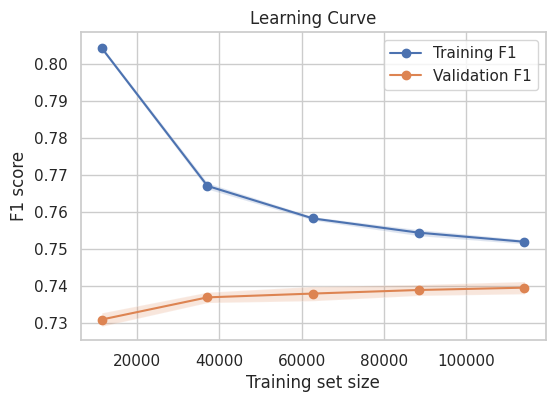

In [80]:
# Learning curve: bias-variance analysis
train_sizes, train_scores, val_scores = learning_curve(
    estimator=final_model,              # refined and selected model
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),# increasing fractions of training data
    cv=5,                                # cross-validation
    scoring="f1",
    n_jobs=1
)

# Compute mean and std of scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Plot learning curve
plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_mean, label="Training F1", marker="o")
plt.plot(train_sizes, val_mean, label="Validation F1", marker="o")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.xlabel("Training set size")
plt.ylabel("F1 score")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

The learning curve shows a clear behavior of the model as the training set size increases\. With smaller training samples, the model achieves a relatively high F1\-score, indicating a strong fit to the available data\. As more data are added, the training performance decreases and stabilizes, reflecting a more realistic fit to a larger and more diverse dataset\. 

At the same time the validation F1\-score shows a modest but consistent improvement, before reaching a plateau around 0\.74\. The limited and stable gap between training and validation performance suggest only mild overfitting and indicates good generalization ability\. Since the validation performance quickly stabilizes, additional data are unikely to bring major improvements and future gains would mainly depend on model or feature refinement\. 

<hr>

The Validation curve illustrates how the model's performance changes as a function of a specific hyperparameter, highlighting the trade\-off between model complexity and generalization\. Analyzing this curve helps verify whether the selected model complexity is appropriate and whether increasing complexity leads to genuine performance gains or to overfitting\. 

In this case the validation curve focuses on the max\_depyh parameter, as it directly regulates model complexity and plays a crucial role in controlling overfitting in tree\-based models\. 

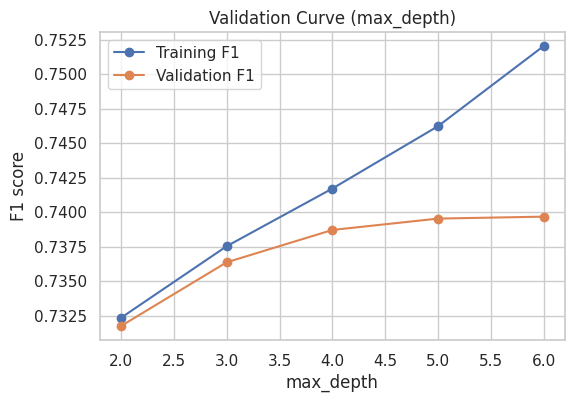

In [43]:
# Validation curve: effect of max_depth on model performance
param_range = [2, 3, 4, 5, 6]

train_scores, val_scores = validation_curve(
    estimator=final_model,
    X=X_train,
    y=y_train,
    param_name="classifier__max_depth",  # hyperparameter to analyze
    param_range=param_range,
    cv=5,
    scoring="f1",
    n_jobs=1
)

# Compute mean scores
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# Plot validation curve
plt.figure(figsize=(6, 4))
plt.plot(param_range, train_mean, label="Training F1", marker="o")
plt.plot(param_range, val_mean, label="Validation F1", marker="o")

plt.xlabel("max_depth")
plt.ylabel("F1 score")
plt.title("Validation Curve (max_depth)")
plt.legend()
plt.grid(True)
plt.show()

The graph shows that, as max\_depth increases, training performance continues to improve, while validation performance quickly reaches a plateau\. This pattern indicates that deeper trees mainly increase model complexity without meaningful gains in generalization\. 

<hr>

In this step several standard classification metrics are computed on the test set to provide a comprehensive evaluation of the model's performance\. Accuracy measures overall correctness, precision quantifies how reliable positive predictions are, recall captures the model's ability to identify positive cases, and the F1\-score summarizes the balance between precision e recall\. 

In [65]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1-score : {f1:.4f}")

Test Accuracy : 0.7352
Test Precision: 0.7313
Test Recall   : 0.7432
Test F1-score : 0.7372


The final model achieves an accuracy of 0\.735, indicating that approximately 74% of test instances are correctly classified\. Precision \(0\.731\) and recall \(0\.743\) are well balanced, suggesting that the model does not strongly favor either false positives or false negatives\. 

The resulting F1\-score \(0\.737\) confirms a stable trade\-off between precision and recall, which is consistent with the optimization objective use during model selection and refinement\. 

These metrics summarize the overall performance of the model, but they do not distinguish between different error types\. The confusion matrix is therefore used to provide a more detailed view on where the model makes correct predictions and where it makes mistakes\. It distinguishes between correctly identified drinkers, missed drinkers and fals alarms\. 

<Figure size 500x500 with 0 Axes>

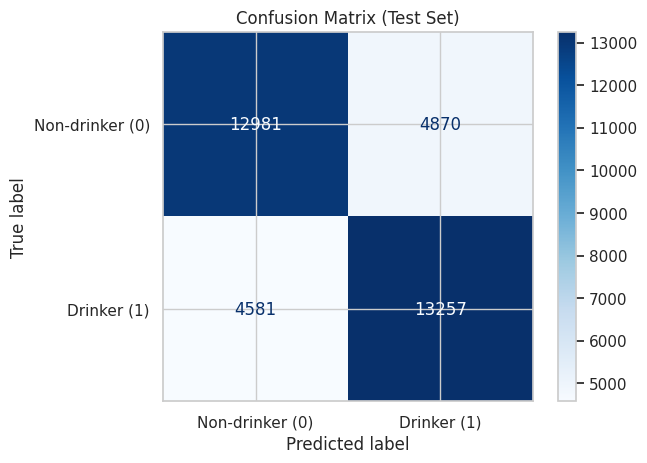

TN=12981, FP=4870, FN=4581, TP=13257


In [68]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-drinker (0)", "Drinker (1)"])

plt.figure(figsize=(5, 5))
disp.plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

The model correctly identifies 12981 non drinkers \(true negatives\) and 13257 drinkers \(true positives\), showing a good ability to recognize both classes\. At the same time 4870 non drinkers are incorrectly classified as drinkers \(false positive\), while 4,581 drinkers are missclassified as non\-drinkers \(false negatives\)\. The relatively balanced magnitude of false positive and false negatives indicates that the model does not strongly favor one class over the other\. 

<hr>

The Precision\-Recall curve shows how the model balances precision and recall across different decision thresholds\. This analysis is particularly useful to assess the model's ability to identify positive cases in a reliable way\.

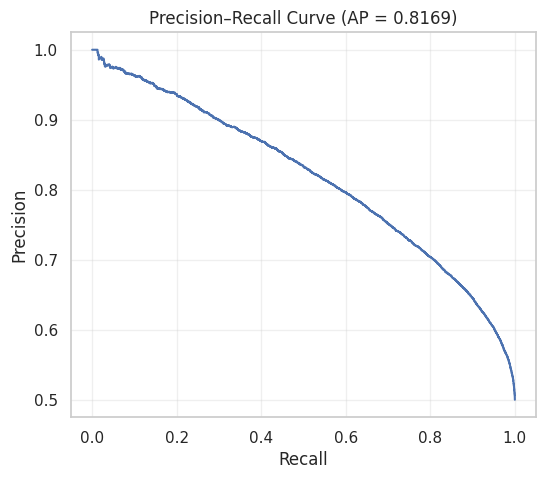

Average Precision (AP): 0.8169


In [71]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (AP = {ap:.4f})")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average Precision (AP): {ap:.4f}")

The curve remains relatively high over a wide range of recall values, indicating that the model is able to identify drinkers while keeping false positives under control\. The high Average Precision \(AP = 0\.82\) confirms that the model maintains strong discriminative power, especially in correctly ranking positive cases\. 

<hr>

The Roc curve is used to evaluate the ability of the model to distinguish between drinkers and non\-drinkers across all possible classification thresholds\. The Area Under the curve \(AUC\) summarizes this behavior into a single value, allowing a threshold\-independet assessment of model performance\. 

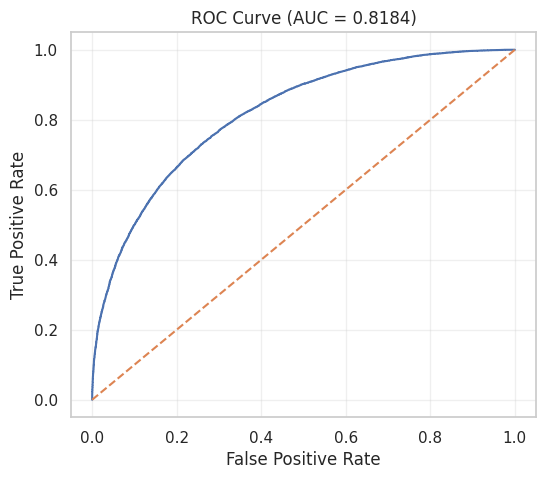

ROC-AUC: 0.8184


In [74]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.4f})")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC: {auc:.4f}")

The obtained ROC curve shows a clear separation from the diagonal corresponding to random classification, with an AUC of approximately 0\.82\. This indicates that the model has a good overall ability to rank drinkers above non\-drinkers\. The smooth shape suggests stable performance across different thresholds, confirming that the model captures meaningful patterns in the data rather than relying on a specific decision cutoff\. 

## Model Interpretation

In this final section, the focus shifts from predictive performance to model interpretability\. The goal is to understand which features drive the model's decisions and how they influence the prediction of alcohol consumption\. To achieve this, two complementary approaches are adopted\. 

The first one is the Feature Importance analysis, which is used to identify the variables that contribute most to the predictions of the selection model\. In tree\-based models such as XGBoost, feature importance provides a global view of how often and how effectively each feature is used to split the data during training\. This analysis ranks features according to their relatively influence of the model's decisions\. 

,feature,importance_mean,importance_std
1,age,0.057879,0.001833
21,urine_protein_5.0,0.043995,0.001333
0,bmi,0.042345,0.000799
20,urine_protein_4.0,0.017558,0.001119
13,SGOT_ALT,0.015876,0.000509
22,urine_protein_6.0,0.010738,0.000438
14,gamma_GTP,0.002413,0.000416
19,urine_protein_3.0,0.001689,0.000521
15,sex_Male,0.001427,0.000188
16,SMK_stat_type_cd_2.0,0.001024,0.000295


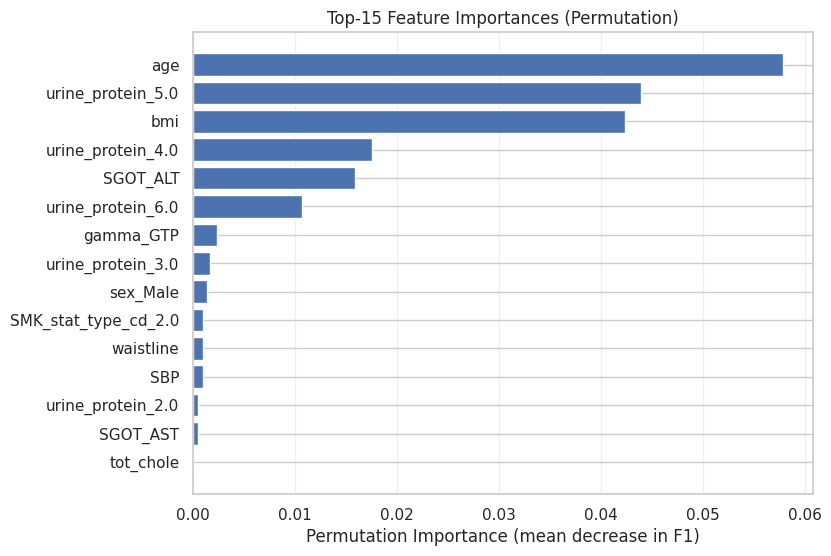

In [44]:
# Try to extract feature names after preprocessing
try:
    feature_names = final_model.named_steps["trans"].get_feature_names_out()
except Exception:
    feature_names = None

perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

importances = perm.importances_mean
stds = perm.importances_std

imp_df = pd.DataFrame({
    "feature": feature_names if feature_names is not None else np.arange(len(importances)),
    "importance_mean": importances,
    "importance_std": stds
}).sort_values("importance_mean", ascending=False)

display(imp_df.head(15))

top = imp_df.head(15).iloc[::-1]  # reverse for nicer plot
plt.figure(figsize=(8, 6))
plt.barh(top["feature"].astype(str), top["importance_mean"])
plt.xlabel("Permutation Importance (mean decrease in F1)")
plt.title("Top-15 Feature Importances (Permutation)")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

From this ranking:

- Age is the most influential variable, indicating that prediction performance decreases the most when this feature is randomly shuffled\. This suggests that age plays a centrale role in distinguishing between drinkers and non\-drinkers\. 

- Several levels of urine\_protein also appear among the top features, confirming their strong associations with the target variable and support their relevance from a clinical perspective\. 

- BMI ranks among the most important predictors, showing that body composition contributes meaningful information to the model beyond basic demographic variables\. 

- Liver\-related biomarkers such as SGOT\_ALT and gamma\-GTP also show non\-negligible importance, which is consistent with known physiological effects of alcohol consumption\. 

Overall, the importance scores are concentrated in a small subset of features, while many variables have near\-zero impact, so the model relies on a limited number of informative predictors rather than spreading importance uniformly across all inputs\. 

While permutation feature importance provides a global view of which variables are most influential, it doesn't explain how features affect individual predictions\. For this reason SHAP is used as a complementary interpretability method\. SHAP quantifies the contribution of each feature at the level of single observations, showing both the direction and the strength of its effect on the model's output\. 

In [92]:
# SHAP — Setup
import shap
import matplotlib.pyplot as plt

assert final_model is not None, "final_model is not defined."
xgb_model = final_model.named_steps["classifier"]


def transform_for_shap(pipe, X):
    """Apply all pipeline steps except the classifier."""
    Xt = X
    for name, step in pipe.steps[:-1]:
        if step is None:
            continue
        Xt = step.transform(Xt)
    try:
        Xt = Xt.toarray()  # sparse -> dense
    except Exception:
        Xt = np.asarray(Xt)
    return Xt


def get_feature_names(pipe, X_fallback, n_features):
    """Get post-transform feature names from 'trans' step; fallback if needed."""
    trans = pipe.named_steps.get("trans", None)
    if trans is not None:
        try:
            names = trans.get_feature_names_out()
            names = np.array(names, dtype=object)
            if len(names) == n_features:
                return names
        except Exception:
            pass

    if hasattr(X_fallback, "columns") and len(X_fallback.columns) == n_features:
        return np.array(X_fallback.columns, dtype=object)

    return np.array([f"f{i}" for i in range(n_features)], dtype=object)


def pick_feature(colnames, raw):
    """Find a transformed column name that matches a raw feature token."""
    matches = [c for c in colnames if c == raw or c.endswith(raw) or raw in c]
    return matches[0] if matches else None

In [95]:
# SHAP — Prepare data for explanations (transform + sample)
X_test_tr = transform_for_shap(final_model, X_test)
feature_names = get_feature_names(final_model, X_train, X_test_tr.shape[1])

X_test_shap = pd.DataFrame(X_test_tr, columns=feature_names)

# Sample for speed (recommended with large datasets)
n_shap = min(5000, len(X_test_shap))
X_shap = X_test_shap.sample(n=n_shap, random_state=42)

# Compute SHAP values (TreeExplainer for XGBoost)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)
base_value = explainer.expected_value

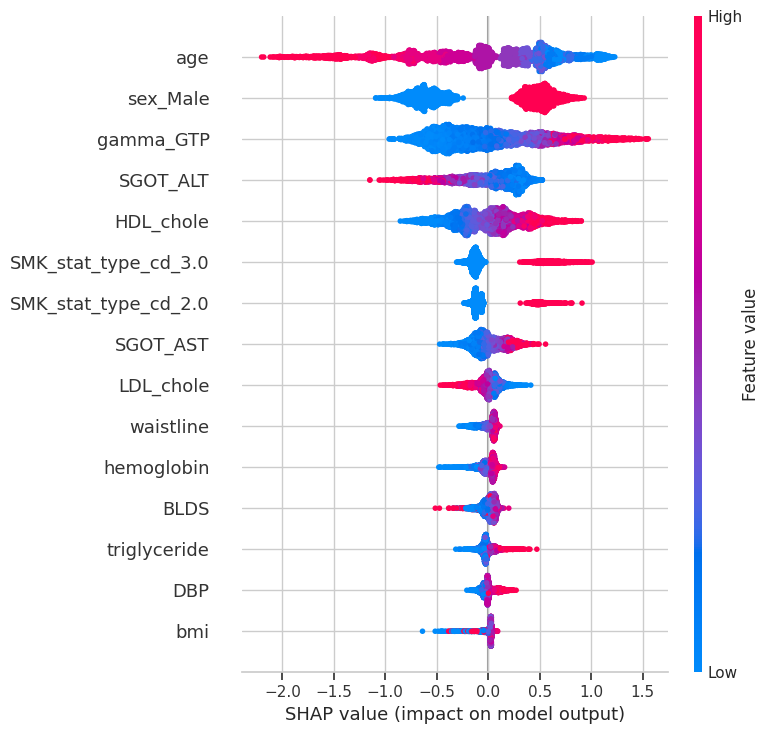

In [98]:
# SHAP Summary (beeswarm) [GLOBAL]
shap.summary_plot(shap_values, X_shap, max_display=15)

The results highlight that the model relies on a relatively small set of clinically meaningful variables, showing clear and consistent patterns across the dataset\. In particular: 

- Sex \(male\) emerges as the most influential feature, with male subjects showing a higher contribution toward the Drinker class\. 

- Liver\-related biomarkers \(e\.g,\. gamma\-GTP, SGOT/ALT\) display a strong positive impact when their values are high, coherently reflecting known associations with alcohol consumption\. 

- Smoking status variables contribute positively to the prediction, capturing behavioral patterns often linked to drinking habits\. 

- Metabolic and anthropometric features \(BMI, waistline, blood pressure\) play a secondary role, refining the prediction without dominating the model's decision process\. 

Among all features, age was selected for further inspection because it emerged as the most informative variable in the global interpretation analysis\. To better understand how age influences the model's predictions and whether its effect is monotonic or interacts with other variables, a SHAP dependence plot is examined\. 

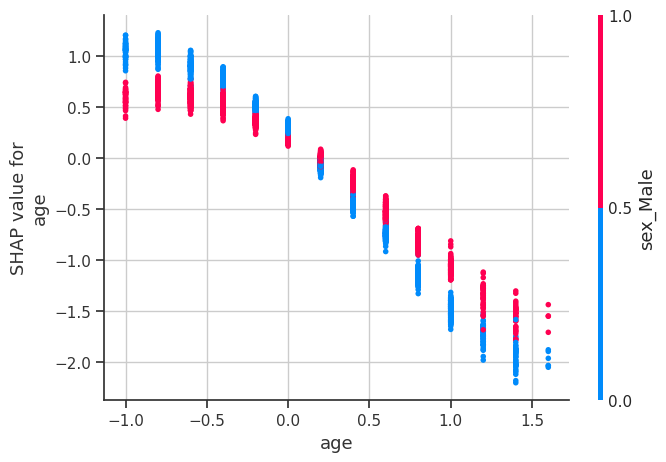

In [104]:
#SHAP Dependence Plot: age [GLOBAL + DIRECTION]
feat_age = pick_feature(X_shap.columns, "age")
if feat_age is None:
    print("Could not find a column matching 'age' in transformed features.")
else:
    shap.dependence_plot(feat_age, shap_values, X_shap)

The SHAP dependence plot for age shows a clear and strong relationship between age and the model output\. As age increases, the SHAP value progressively decreases, indicanting that higher age contributes negatively to the predicted probability of being a drinker\. The pattern is smooth and approximately monotonic, suggesting that age has a consistent effect across its range rather than acting only at specific thresholds\. This indicates that the model relies on age as a stable and well\-behaved predictor rather than exploiting local irregularities\. 

The plot reveals a clear interaction between age and sex\. For lower age values, SHAP values are predominantly positive, indicating that younger individuals contribute more strongly toward the Drinker class\. In this range, male subjects \(red point\) tend to have higher SHAP values than females, suggesting a stronger association with drinking behavior at younger ages\. 

As age increases, SHAP values progressively decrease and become negative, indicating a shift toward the Non\-drinker class\. In this higher age range, female subjects \(blue points\) show more negative SHAP values than male, meaning that increasing age reduces the predicted probability of being a drinker more strongly for women than for men\. The apparent inversion of colors across the age range reflects this interaction effect: the impact of age on the prediction is not uniform, but depends on the individual's sex\. 

Gamma\-glutamyl transferase \(gamma\_GTP\) was selected for further analysis because it is one of the clinical biomarkers most strongly associated with alcohol consumption\. Gamma\_GTP is a liver enzyme commonly used as an indicator of hepatic stress and alcohol\-related liver damage, making it highly relevant from a clinical perspective\. 

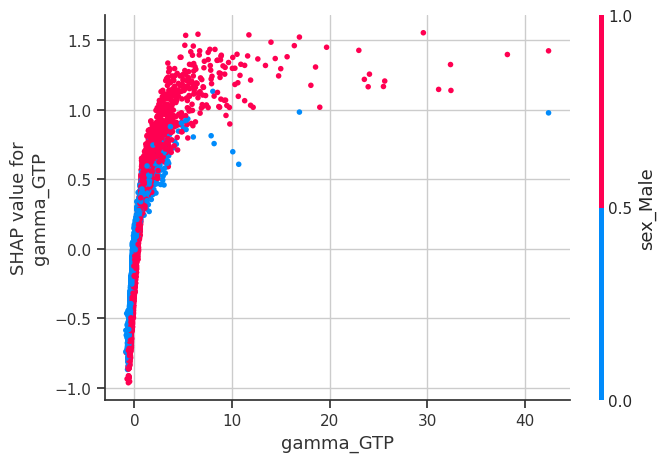

In [107]:
# =========================
# SHAP Dependence Plot: gamma_GTP [GLOBAL + DIRECTION]
# =========================
feat_ggtp = pick_feature(X_shap.columns, "gamma_GTP")
if feat_ggtp is None:
    print("Could not find a column matching 'gamma_GTP' in transformed features.")
else:
    shap.dependence_plot(feat_ggtp, shap_values, X_shap)

The SHAP dependence plot shows a clear and non\-linear relationship between gamma\_GTP and the model output\. At low values of gamma\_GTP, SHAP values are mostly negative, indicating a reduced contribution toward the Drinker class\. As gamma\_GTP increases, SHAP values rapidly become positive and then gradually plateau, suggesting that higher enzyme levels strongly increase the predicted probebility of being a drinker, with diminishing additional impact at very high values\. This pattern reflects a saturation effect: once gamma\_GTP exceeds a certain threshold, further increases add limited new information to the prediction\. 

The color coding highlights a consistent interaction with sex\. For comparable gamma\_GTP values, male subjects \(red points\) tend to have higher SHAP values than females \(blue points\), indicating that elevated gamma\_GTP contributes more strongly to the Drinker prediction in males\. This suggests that the model captures a sex\-specific effect, where increased gamma\_GTP levels are interpreted as a stronger signal of alcohol consumption in men than in women, in line with known clinical differences in alcohol metabolism and liver response\. 

## Conclusion

In conclusion, this study shows that alcohol consumption status can be effectively predicted using health\-related and demographic variables within a structured machine learning framework\. The final Gradient Boosting model achieved a stable test F1\-score of approximately 0\.74, indicating a good balance between precision and recall and a reliable identification of both drinkers and non\-drinkers\.

Model interpretation was central to the analysis\. Feature importance and SHAP results consistently highlighted clinically meaningful variables,  such as age, sex, gamma\-GTP, liver enzymes and smoking status, confirming that drinking behavior is associated with both biological markers and lifestyle factors\. These findings emphasize the multifactorial nature of alcohol consumption\.

However, some limitations should be considered\. Drinking status is derived from standardized health screening records based on patient questionnaires, meaning that potential reporting bias cannot be excluded\. Moreover, the observational nature of the dataset and the absence of psychological or socioeconomic variables limit causal interpretation and generalizability\.

Overall, this work demonstrates how interpretable machine learning can provide both solid predictive performance and meaningful public health insights, supporting a more data\-driven understanding of alcohol consumption patterns\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c4b407fa-ecd6-40e5-870d-49f3d581f8f2' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>